In [48]:
import pyvista as pv
import numpy as np
import xarray as xr
from pathlib import Path

folder = Path("../out")
files = sorted(folder.glob("snapshot_*.vti"), key=lambda f: int(f.stem.split('_')[1]))

data_list = []
for file in files:
    grid = pv.read(file)

    dims = grid.dimensions
    spacing = grid.spacing
    origin = grid.origin
    arr = grid["a"].reshape(dims[::-1])  # (z, y, x)
    data_list.append(arr)

data_array = np.stack(data_list)  # (time, z, y, x)

In [49]:
rdy_data = data_array[:, 0, :, :]

In [50]:
ds = xr.open_dataset("../data/example_long_out.nc")
my_data = ds["data"][0, :, :, 0::2]
my_data = my_data[:, 1:-1, 1:-1]

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def anim_side_by_side(data1, name1, data2, name2, snapshots=10):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    im1 = ax1.imshow(data1[0], cmap="viridis", origin="lower", animated=True)
    im2 = ax2.imshow(data2[0], cmap="plasma", origin="lower", animated=True)
    ax1.set_title(f"{name1} - Snapshot 0")
    ax2.set_title(f"{name2} - Snapshot 0")
    global_min = min(np.min(data1), np.min(data2))
    global_max = max(np.max(data1), np.max(data2))
    im1.set_clim(vmin=global_min, vmax=global_max)
    im2.set_clim(vmin=global_min, vmax=global_max)
    def update(frame):
        im1.set_array(data1[frame])
        im2.set_array(data2[frame])
        ax1.set_title(f"{name1} - Snapshot {frame}")
        ax2.set_title(f"{name2} - Snapshot {frame}")
        return im1, im2

    ani = FuncAnimation(fig, update, frames=snapshots, interval=50, blit=True)

    ani.save(f"{name1}_{name2}_side_by_side.mp4", writer="ffmpeg", fps=20, dpi=200)


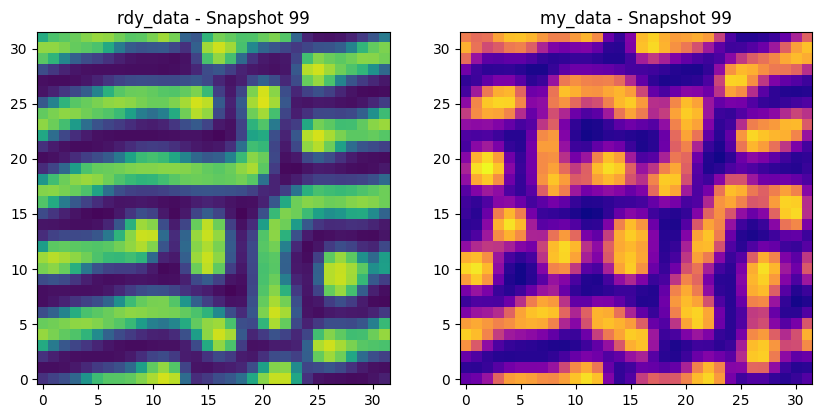

In [52]:
# anim(rdy_data, "rdy_data", snapshots=rdy_data.shape[0])
# anim(my_data, "my_data", snapshots=my_data.shape[0])
anim_side_by_side(rdy_data, "rdy_data", my_data, "my_data", snapshots=min(rdy_data.shape[0], my_data.shape[0]))